In [1]:
import io
import os
import pickle
import json
import h5py

import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

from sklearn.decomposition import NMF, PCA

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm, SymLogNorm

In [2]:
from pyFAI.azimuthalIntegrator import AzimuthalIntegrator
from pyFAI.detectors import Detector

from ePDF.DAG.diffraction import integrate_single

In [3]:
# Read the DM4 file
# Open the datacube as a 4D numpy array

with h5py.File('data/TiO2_dataset.h5', 'r') as f:
    # Load the datacube into memory
    X = np.array(f['X4D'])
    Xr = np.array(f['coordinates/x_real'])
    Yr = np.array(f['coordinates/y_real'])
    Xq = np.array(f['coordinates/x_reciprocal'])
    Yq = np.array(f['coordinates/y_reciprocal'])
    meta = json.loads(f['metadata'][()])
    beamstop = np.array(f['coordinates/beamstop'])

x_real, y_real, x_reci, y_reci = X.shape

Xf = X.reshape(X.shape[0] * X.shape[1], X.shape[2] * X.shape[3])
Xf = Xf.clip(min=0, max=1e32)

print(x_real, y_real, x_reci, y_reci)

26 78 187 187


In [4]:
import time
from math import log, sqrt
from functools import partial

from sklearn.utils import check_random_state
from sklearn.decomposition._nmf import _initialize_nmf, _beta_divergence
from sklearn.decomposition._cdnmf_fast import _update_cdnmf_fast

from scipy import fftpack, linalg, sparse
from sklearn.utils import check_random_state, check_array
from sklearn.utils.extmath import safe_sparse_dot

def random_axis_sample(A, l, axis, random_state):
    return random_state.choice(A.shape[axis], size=l, replace=False)

def random_gaussian_map(A, l, axis, random_state):
    return random_state.standard_normal(size=(A.shape[axis], l)).astype(A.dtype)

def random_uniform_map(A, l, axis, random_state):
    return random_state.uniform(-1, 1, size=(A.shape[axis], l)).astype(A.dtype)

def sparse_random_map(A, l, axis, density, random_state):
    values = (-sqrt(1. / density), sqrt(1. / density))
    data_rvs = partial(random_state.choice, values)
    return sparse.random(A.shape[axis], l, density=density, data_rvs=data_rvs,
                         random_state=random_state, dtype=A.dtype)

def johnson_lindenstrauss(A, l, axis=1, random_state=None):
    random_state = check_random_state(random_state)
    A = np.asarray(A)
    Omega = random_gaussian_map(A, l, axis, random_state)
    if axis == 0:
        return Omega.T.dot(A)
    return A.dot(Omega)

def sparse_johnson_lindenstrauss(A, l, density=None, axis=1, random_state=None):
    random_state = check_random_state(random_state)
    A = np.asarray(A)
    if density is None:
        density = log(A.shape[0]) / A.shape[0]
    Omega = sparse_random_map(A, l, axis, density, random_state)
    if axis == 0:
        return safe_sparse_dot(Omega.T, A)
    return safe_sparse_dot(A, Omega)

def orthonormalize(A, overwrite_a=True, check_finite=False):
    Q, _ = linalg.qr(A, overwrite_a=overwrite_a, check_finite=check_finite,
                     mode='economic', pivoting=False)
    return Q

def perform_subspace_iterations(A, Q, n_iter=2, axis=1):
    if axis == 0:
        Q = Q.T
    Q = orthonormalize(Q)
    for _ in range(n_iter):
        if axis == 0:
            Z = orthonormalize(A.dot(Q))
            Q = orthonormalize(A.T.dot(Z))
        else:
            Z = orthonormalize(A.T.dot(Q))
            Q = orthonormalize(A.dot(Z))
    if axis == 0:
        return Q.T
    return Q

def conjugate_transpose(A):
    if A.dtype == np.complexfloating:
        return A.conj().T
    return A.T

def _compute_rqb(A, rank, oversample, n_subspace, sparse, random_state):
    if sparse:
        Q = sparse_johnson_lindenstrauss(A, rank + oversample,
                                         random_state=random_state)
    else:
        Q = johnson_lindenstrauss(A, rank + oversample, random_state=random_state)
    if n_subspace > 0:
        Q = perform_subspace_iterations(A, Q, n_iter=n_subspace, axis=1)
    else:
        Q = orthonormalize(Q)
    B = conjugate_transpose(Q).dot(A)
    return Q, B

def compute_rqb(A, rank, oversample=20, n_subspace=2, n_blocks=1, sparse=False,
                random_state=None):
    if n_blocks > 1:
        m, n = A.shape
        row_sets = np.array_split(range(m), n_blocks)
        Q_block = []
        K = []
        for rows in row_sets:
            Qtemp, Ktemp = _compute_rqb(np.asarray_chkfinite(A[rows, :]), 
                rank=rank, oversample=oversample, n_subspace=n_subspace, 
                sparse=sparse, random_state=random_state)
            Q_block.append(Qtemp)
            K.append(Ktemp)
        Q_small, B = _compute_rqb(
            np.concatenate(K, axis=0), rank=rank, oversample=oversample,
            n_subspace=n_subspace, sparse=sparse, random_state=random_state)
        Q_small = np.vsplit(Q_small, n_blocks)
        Q = [Q_block[i].dot(Q_small[i]) for i in range(n_blocks)]
        Q = np.concatenate(Q, axis=0)
    else:
        Q, B = _compute_rqb(np.asarray_chkfinite(A), 
            rank=rank, oversample=oversample, n_subspace=n_subspace,
            sparse=sparse, random_state=random_state)
    return Q, B

def nmf(X, rank, init='nndsvd', maxiter=200, calculate_loss=False, 
                 QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                 random_state=None):
    random_state = check_random_state(random_state)
    X = np.asarray_chkfinite(X)
    X = check_array(X, accept_sparse="csr")
    m, n = X.shape
    flipped = False
    if n > m:
        X = X.T
        m, n = X.shape
        flipped = True
    if np.any(X < 0):
        raise ValueError("Input matrix with nonnegative elements is required.")
        
    W, H = _initialize_nmf(X, rank, init=init, eps=1e-6, random_state=random_state)
    Ht = np.array(H.T, order='C')

    if QB_project:
        Q, B = compute_rqb(X, rank, oversample=oversample,
                        n_subspace=n_subspace, random_state=random_state)
        W_tilde = Q.T.dot(W)
    
    if calculate_loss:
        losses = []
        tols = []

    violation = 0.0
    for niter in range(maxiter):
        if QB_project:
            WtW = W.T.dot(W)
            BtW = B.T.dot(W_tilde)
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation = _update_cdnmf_fast(Ht, WtW, BtW, permutation.astype(np.intp))
            
            HHt = Ht.T.dot(Ht)
            BHt = Q.dot(B.dot(Ht))
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation += _update_cdnmf_fast(W, HHt, BHt, permutation.astype(np.intp))

            W_tilde = Q.T.dot(W)
        else:
            WtW = W.T.dot(W)
            XtW = X.T.dot(W)
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation = _update_cdnmf_fast(Ht, WtW, XtW, permutation.astype(np.intp))

            HHt = np.dot(Ht.T, Ht)
            XHt = safe_sparse_dot(X, Ht)
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation += _update_cdnmf_fast(W, HHt, XHt, permutation.astype(np.intp))

        if niter == 0:
            if violation == 0: break
            violation_init = violation

        if calculate_loss:
            if flipped:
                loss = _beta_divergence(X, W, Ht.T, 2, square_root=True)
            else:
                loss = _beta_divergence(X, W, Ht.T, 2, square_root=True)
            losses.append(loss)
            tols.append(violation / violation_init)

    if calculate_loss:
        if flipped:
            return(Ht, W.T, np.array(losses), np.array(tols))
        return(W, Ht.T, np.array(losses), np.array(tols))
    if flipped:
        return(Ht, W.T)
    return(W, Ht.T)

In [5]:
k_NMF = 3

In [6]:
execution_times = {}

In [7]:
if os.path.exists('factorizations/TiO2_nmf_NQ_100.pkl'):
    with open('factorizations/TiO2_nmf_NQ_100.pkl', 'rb') as f:
        W_NQ_100, H_NQ_100 = pickle.load(f)
        # Note: If loaded from a file, we won't have the execution time unless we measure it again, 
        # but since we want the actual measured time we will skip setting it or set it to None.
else:
    start = time.time()
    W_NQ_100, H_NQ_100 = nmf(Xf, k_NMF, init='nndsvdar', maxiter=100, calculate_loss=False, 
                     QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                     random_state=55)
    stop = time.time()
    execution_times[100] = stop - start
    print(stop - start)
    with open('factorizations/TiO2_nmf_NQ_100.pkl', 'wb') as f:
        pickle.dump((W_NQ_100, H_NQ_100), f)

scale = H_NQ_100.max(axis=1)
H_NQ_100 /= scale[:, np.newaxis]
W_NQ_100 *= scale

1.9753656387329102


C:\Users\Andreas\AppData\Local\Temp\ipykernel_18856\739545535.py:67: DeprecationWarning: Converting `np.complex` to a dtype is deprecated. The current result is `complex128` which is not strictly correct.
  if A.dtype == np.complexfloating:


In [8]:
if os.path.exists('factorizations/TiO2_nmf_NQ_200.pkl'):
    with open('factorizations/TiO2_nmf_NQ_200.pkl', 'rb') as f:
        W_NQ_200, H_NQ_200 = pickle.load(f)
else:
    start = time.time()
    W_NQ_200, H_NQ_200 = nmf(Xf, k_NMF, init='nndsvdar', maxiter=200, calculate_loss=False, 
                     QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                     random_state=55)
    stop = time.time()
    execution_times[200] = stop - start
    print(stop - start)
    with open('factorizations/TiO2_nmf_NQ_200.pkl', 'wb') as f:
        pickle.dump((W_NQ_200, H_NQ_200), f)

scale = H_NQ_200.max(axis=1)
H_NQ_200 /= scale[:, np.newaxis]
W_NQ_200 *= scale

C:\Users\Andreas\AppData\Local\Temp\ipykernel_18856\739545535.py:67: DeprecationWarning: Converting `np.complex` to a dtype is deprecated. The current result is `complex128` which is not strictly correct.
  if A.dtype == np.complexfloating:


1.9236533641815186


In [9]:
if os.path.exists('factorizations/TiO2_nmf_NQ_500.pkl'):
    with open('factorizations/TiO2_nmf_NQ_500.pkl', 'rb') as f:
        W_NQ_500, H_NQ_500 = pickle.load(f)
else:
    start = time.time()
    W_NQ_500, H_NQ_500 = nmf(Xf, k_NMF, init='nndsvdar', maxiter=500, calculate_loss=False, 
                     QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                     random_state=55)
    stop = time.time()
    execution_times[500] = stop - start
    print(stop - start)
    with open('factorizations/TiO2_nmf_NQ_500.pkl', 'wb') as f:
        pickle.dump((W_NQ_500, H_NQ_500), f)

scale = H_NQ_500.max(axis=1)
H_NQ_500 /= scale[:, np.newaxis]
W_NQ_500 *= scale

C:\Users\Andreas\AppData\Local\Temp\ipykernel_18856\739545535.py:67: DeprecationWarning: Converting `np.complex` to a dtype is deprecated. The current result is `complex128` which is not strictly correct.
  if A.dtype == np.complexfloating:


2.441568613052368


In [10]:
if os.path.exists('factorizations/TiO2_nmf_NQ_2000.pkl'):
    with open('factorizations/TiO2_nmf_NQ_2000.pkl', 'rb') as f:
        W_NQ_2000, H_NQ_2000 = pickle.load(f)
else:
    start = time.time()
    W_NQ_2000, H_NQ_2000 = nmf(Xf, k_NMF, init='nndsvdar', maxiter=2000, calculate_loss=False, 
                     QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                     random_state=55)
    stop = time.time()
    execution_times[2000] = stop - start
    print(stop - start)
    with open('factorizations/TiO2_nmf_NQ_2000.pkl', 'wb') as f:
        pickle.dump((W_NQ_2000, H_NQ_2000), f)

scale = H_NQ_2000.max(axis=1)
H_NQ_2000 /= scale[:, np.newaxis]
W_NQ_2000 *= scale

C:\Users\Andreas\AppData\Local\Temp\ipykernel_18856\739545535.py:67: DeprecationWarning: Converting `np.complex` to a dtype is deprecated. The current result is `complex128` which is not strictly correct.
  if A.dtype == np.complexfloating:


4.632437229156494


In [11]:
if os.path.exists('factorizations/TiO2_nmf_NQ_5000.pkl'):
    with open('factorizations/TiO2_nmf_NQ_5000.pkl', 'rb') as f:
        W_NQ_5000, H_NQ_5000 = pickle.load(f)
else:
    start = time.time()
    W_NQ_5000, H_NQ_5000 = nmf(Xf, k_NMF, init='nndsvdar', maxiter=5000, calculate_loss=False, 
                     QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                     random_state=55)
    stop = time.time()
    execution_times[5000] = stop - start
    print(stop - start)
    with open('factorizations/TiO2_nmf_NQ_5000.pkl', 'wb') as f:
        pickle.dump((W_NQ_5000, H_NQ_5000), f)

scale = H_NQ_5000.max(axis=1)
H_NQ_5000 /= scale[:, np.newaxis]
W_NQ_5000 *= scale

C:\Users\Andreas\AppData\Local\Temp\ipykernel_18856\739545535.py:67: DeprecationWarning: Converting `np.complex` to a dtype is deprecated. The current result is `complex128` which is not strictly correct.
  if A.dtype == np.complexfloating:


6.913180112838745


In [12]:
if os.path.exists('factorizations/TiO2_nmf_NQ_10000.pkl'):
    with open('factorizations/TiO2_nmf_NQ_10000.pkl', 'rb') as f:
        W_NQ_10000, H_NQ_10000 = pickle.load(f)
else:
    start = time.time()
    W_NQ_10000, H_NQ_10000 = nmf(Xf, k_NMF, init='nndsvdar', maxiter=10000, calculate_loss=False, 
                     QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                     random_state=55)
    stop = time.time()
    execution_times[10000] = stop - start
    print(stop - start)
    with open('factorizations/TiO2_nmf_NQ_10000.pkl', 'wb') as f:
        pickle.dump((W_NQ_10000, H_NQ_10000), f)

scale = H_NQ_10000.max(axis=1)
H_NQ_10000 /= scale[:, np.newaxis]
W_NQ_10000 *= scale

C:\Users\Andreas\AppData\Local\Temp\ipykernel_18856\739545535.py:67: DeprecationWarning: Converting `np.complex` to a dtype is deprecated. The current result is `complex128` which is not strictly correct.
  if A.dtype == np.complexfloating:


11.691510677337646


In [13]:
if os.path.exists('factorizations/TiO2_nmf_NQ_20000.pkl'):
    with open('factorizations/TiO2_nmf_NQ_20000.pkl', 'rb') as f:
        W_NQ_20000, H_NQ_20000 = pickle.load(f)
else:
    start = time.time()
    W_NQ_20000, H_NQ_20000 = nmf(Xf, k_NMF, init='nndsvdar', maxiter=20000, calculate_loss=False, 
                     QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                     random_state=55)
    stop = time.time()
    execution_times[20000] = stop - start
    print(stop - start)
    with open('factorizations/TiO2_nmf_NQ_20000.pkl', 'wb') as f:
        pickle.dump((W_NQ_20000, H_NQ_20000), f)

scale = H_NQ_20000.max(axis=1)
H_NQ_20000 /= scale[:, np.newaxis]
W_NQ_20000 *= scale

C:\Users\Andreas\AppData\Local\Temp\ipykernel_18856\739545535.py:67: DeprecationWarning: Converting `np.complex` to a dtype is deprecated. The current result is `complex128` which is not strictly correct.
  if A.dtype == np.complexfloating:


24.266344785690308


In [14]:
if os.path.exists('factorizations/TiO2_nmf_NQ_50000.pkl'):
    with open('factorizations/TiO2_nmf_NQ_50000.pkl', 'rb') as f:
        W_NQ_50000, H_NQ_50000 = pickle.load(f)
else:
    start = time.time()
    W_NQ_50000, H_NQ_50000 = nmf(Xf, k_NMF, init='nndsvdar', maxiter=50000, calculate_loss=False, 
                     QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                     random_state=55)
    stop = time.time()
    execution_times[50000] = stop - start
    print(stop - start)
    with open('factorizations/TiO2_nmf_NQ_50000.pkl', 'wb') as f:
        pickle.dump((W_NQ_50000, H_NQ_50000), f)

scale = H_NQ_50000.max(axis=1)
H_NQ_50000 /= scale[:, np.newaxis]
W_NQ_50000 *= scale

C:\Users\Andreas\AppData\Local\Temp\ipykernel_18856\739545535.py:67: DeprecationWarning: Converting `np.complex` to a dtype is deprecated. The current result is `complex128` which is not strictly correct.
  if A.dtype == np.complexfloating:


64.01317977905273


In [15]:
if os.path.exists('factorizations/TiO2_nmf_NQ_100000.pkl'):
    with open('factorizations/TiO2_nmf_NQ_100000.pkl', 'rb') as f:
        W_NQ_100000, H_NQ_100000 = pickle.load(f)
else:
    start = time.time()
    W_NQ_100000, H_NQ_100000 = nmf(Xf, k_NMF, init='nndsvdar', maxiter=100000, calculate_loss=False, 
                     QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                     random_state=55)
    stop = time.time()
    execution_times[100000] = stop - start
    print(stop - start)
    with open('factorizations/TiO2_nmf_NQ_100000.pkl', 'wb') as f:
        pickle.dump((W_NQ_100000, H_NQ_100000), f)

scale = H_NQ_100000.max(axis=1)
H_NQ_100000 /= scale[:, np.newaxis]
W_NQ_100000 *= scale

C:\Users\Andreas\AppData\Local\Temp\ipykernel_18856\739545535.py:67: DeprecationWarning: Converting `np.complex` to a dtype is deprecated. The current result is `complex128` which is not strictly correct.
  if A.dtype == np.complexfloating:


103.54448890686035


In [16]:
if os.path.exists('factorizations/TiO2_nmf_NQ_200000.pkl'):
    with open('factorizations/TiO2_nmf_NQ_200000.pkl', 'rb') as f:
        W_NQ_200000, H_NQ_200000 = pickle.load(f)
else:
    start = time.time()
    W_NQ_200000, H_NQ_200000 = nmf(Xf, k_NMF, init='nndsvdar', maxiter=200000, calculate_loss=False, 
                     QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                     random_state=55)
    stop = time.time()
    execution_times[200000] = stop - start
    print(stop - start)
    with open('factorizations/TiO2_nmf_NQ_200000.pkl', 'wb') as f:
        pickle.dump((W_NQ_200000, H_NQ_200000), f)

scale = H_NQ_200000.max(axis=1)
H_NQ_200000 /= scale[:, np.newaxis]
W_NQ_200000 *= scale

C:\Users\Andreas\AppData\Local\Temp\ipykernel_18856\739545535.py:67: DeprecationWarning: Converting `np.complex` to a dtype is deprecated. The current result is `complex128` which is not strictly correct.
  if A.dtype == np.complexfloating:


209.2489879131317


In [17]:
if os.path.exists('factorizations/TiO2_nmf_NQ2_1000.pkl'):
    with open('factorizations/TiO2_nmf_NQ2_1000.pkl', 'rb') as f:
        W_NQ, H_NQ = pickle.load(f)
else:
    start = time.time()
    W_NQ, H_NQ = nmf(Xf, k_NMF, init='nndsvdar', maxiter=1000, calculate_loss=False, 
                     QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                     random_state=55)
    stop = time.time()
    execution_times[1000] = stop - start
    print(stop - start)
    with open('factorizations/TiO2_nmf_NQ_1000.pkl', 'wb') as f:
        pickle.dump((W_NQ, H_NQ), f)

scale = H_NQ.max(axis=1)
H_NQ /= scale[:, np.newaxis]
W_NQ *= scale

C:\Users\Andreas\AppData\Local\Temp\ipykernel_18856\739545535.py:67: DeprecationWarning: Converting `np.complex` to a dtype is deprecated. The current result is `complex128` which is not strictly correct.
  if A.dtype == np.complexfloating:


2.8808789253234863


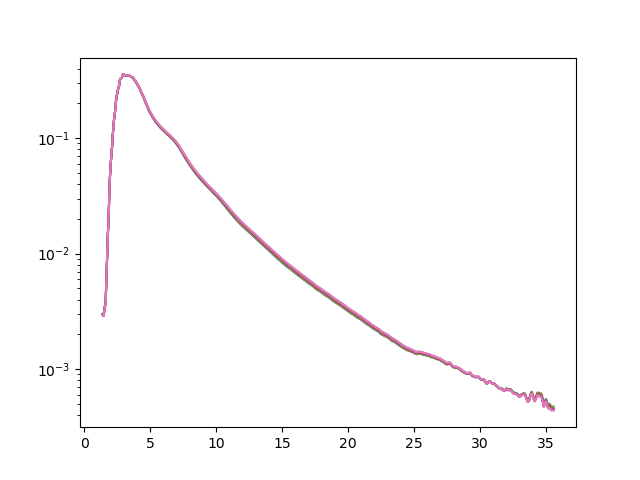

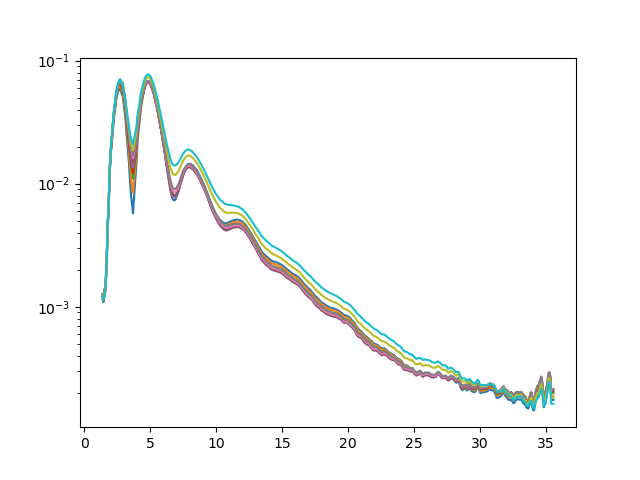

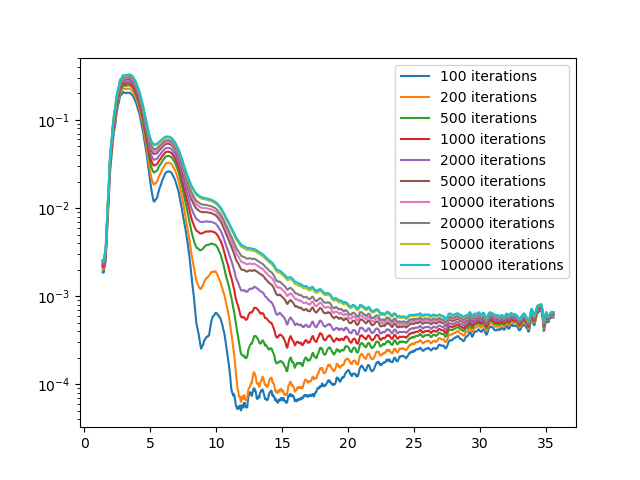

In [18]:

labels = [100,200,500,1000,2000,5000,10000,20000, 50000, 100000, 200000]

plt.figure()
for ix, component in enumerate([H_NQ_100[0], H_NQ_200[0], H_NQ_500[0], H_NQ[0], H_NQ_2000[0], H_NQ_5000[0], H_NQ_10000[0]]):
    diff = component.reshape((x_reci, y_reci))
    QA, I, ai = integrate_single(diff, meta, beamstop.T, ai_res=2**11, return_AI=True)
    plt.plot(QA, I, label=str(labels[ix]) + ' iterations')

plt.yscale('log')

plt.figure()
for ix, component in enumerate([H_NQ_100[1], H_NQ_200[1], H_NQ_500[1], H_NQ[1], H_NQ_2000[1], H_NQ_5000[1], H_NQ_10000[1], H_NQ_20000[1], H_NQ_100000[1], H_NQ_200000[1]]):
    diff = component.reshape((x_reci, y_reci))
    QA, I, ai = integrate_single(diff, meta, beamstop.T, ai_res=2**11, return_AI=True)
    plt.plot(QA, I, label=str(labels[ix]) + ' iterations')

plt.yscale('log')

plt.figure()
for ix, component in enumerate([H_NQ_100[2], H_NQ_200[2], H_NQ_500[2], H_NQ[2], H_NQ_2000[2], H_NQ_5000[2], H_NQ_10000[2], H_NQ_20000[2], H_NQ_100000[2], H_NQ_200000[2]]):
    diff = component.reshape((x_reci, y_reci))
    QA, I, ai = integrate_single(diff, meta, beamstop.T, ai_res=2**11, return_AI=True)
    plt.plot(QA, I, label=str(labels[ix]) + ' iterations')

plt.yscale('log')
plt.legend()

In [19]:
from ePDF.DAG.pdf import pdf_optimize

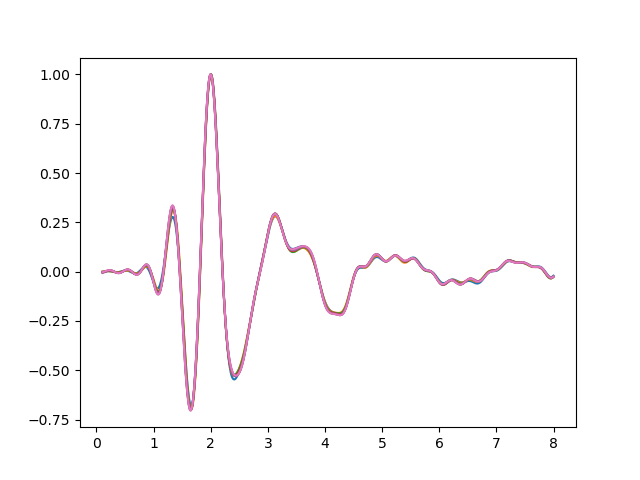

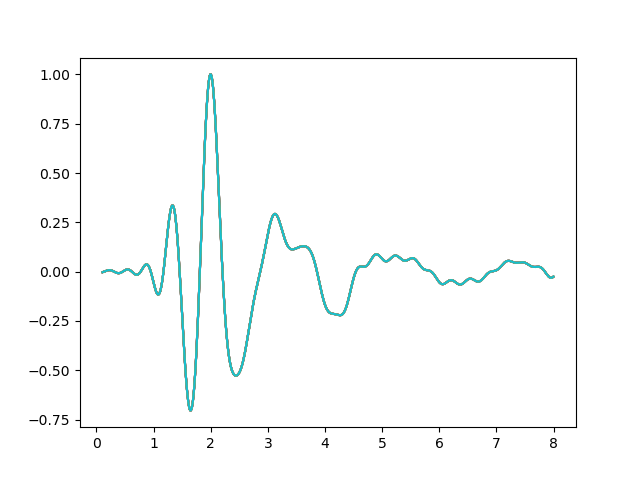

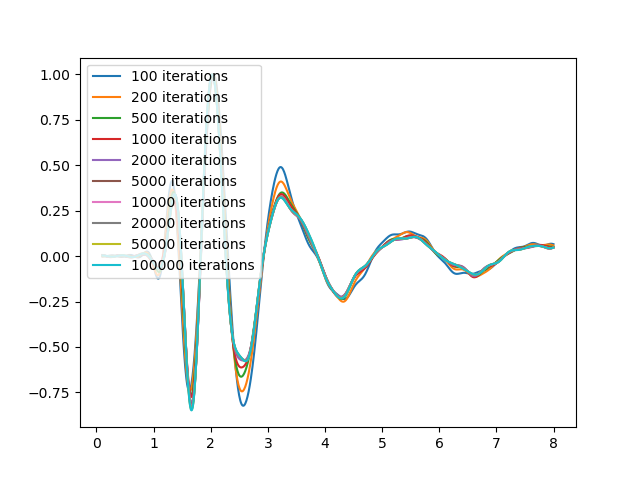

In [20]:
labels = [100,200,500,1000,2000,5000,10000,20000, 50000, 100000, 200000]

plt.figure()
for ix, component in enumerate([H_NQ_100[0], H_NQ_200[0], H_NQ_500[0], H_NQ[0], H_NQ_2000[0], H_NQ_5000[0], H_NQ_10000[0]]):
    diff = component.reshape((x_reci, y_reci))
    QA, I, ai = integrate_single(diff, meta, beamstop.T, ai_res=2**11, return_AI=True)
    pdfr, pdfgr, [qmin, qmax, p] = pdf_optimize(QA, I, qmin=2.5, qmax=20, rpolyrange=np.arange(1, 2, 0.01))
    plt.plot(pdfr[pdfr < 8], pdfgr[pdfr < 8]/pdfgr.max(), label=str(labels[ix]) + ' iterations')


plt.figure()
for ix, component in enumerate([H_NQ_100[1], H_NQ_200[1], H_NQ_500[1], H_NQ[1], H_NQ_2000[1], H_NQ_5000[1], H_NQ_10000[1], H_NQ_20000[1], H_NQ_100000[1], H_NQ_200000[1]]):
    diff = component.reshape((x_reci, y_reci))
    pdfr, pdfgr, [qmin, qmax, p] = pdf_optimize(QA, I, qmin=2.5, qmax=20, rpolyrange=np.arange(1, 2, 0.01))
    plt.plot(pdfr[pdfr < 8], pdfgr[pdfr < 8]/pdfgr.max(), label=str(labels[ix]) + ' iterations')


plt.figure()
for ix, component in enumerate([H_NQ_100[2], H_NQ_200[2], H_NQ_500[2], H_NQ[2], H_NQ_2000[2], H_NQ_5000[2], H_NQ_10000[2], H_NQ_20000[2], H_NQ_100000[2], H_NQ_200000[2]]):
    diff = component.reshape((x_reci, y_reci))
    QA, I, ai = integrate_single(diff, meta, beamstop.T, ai_res=2**11, return_AI=True)
    pdfr, pdfgr, [qmin, qmax, p] = pdf_optimize(QA, I, qmin=2.5, qmax=20, rpolyrange=np.arange(1, 2, 0.01))
    plt.plot(pdfr[pdfr < 8], pdfgr[pdfr < 8]/pdfgr.max(), label=str(labels[ix]) + ' iterations')


plt.legend()

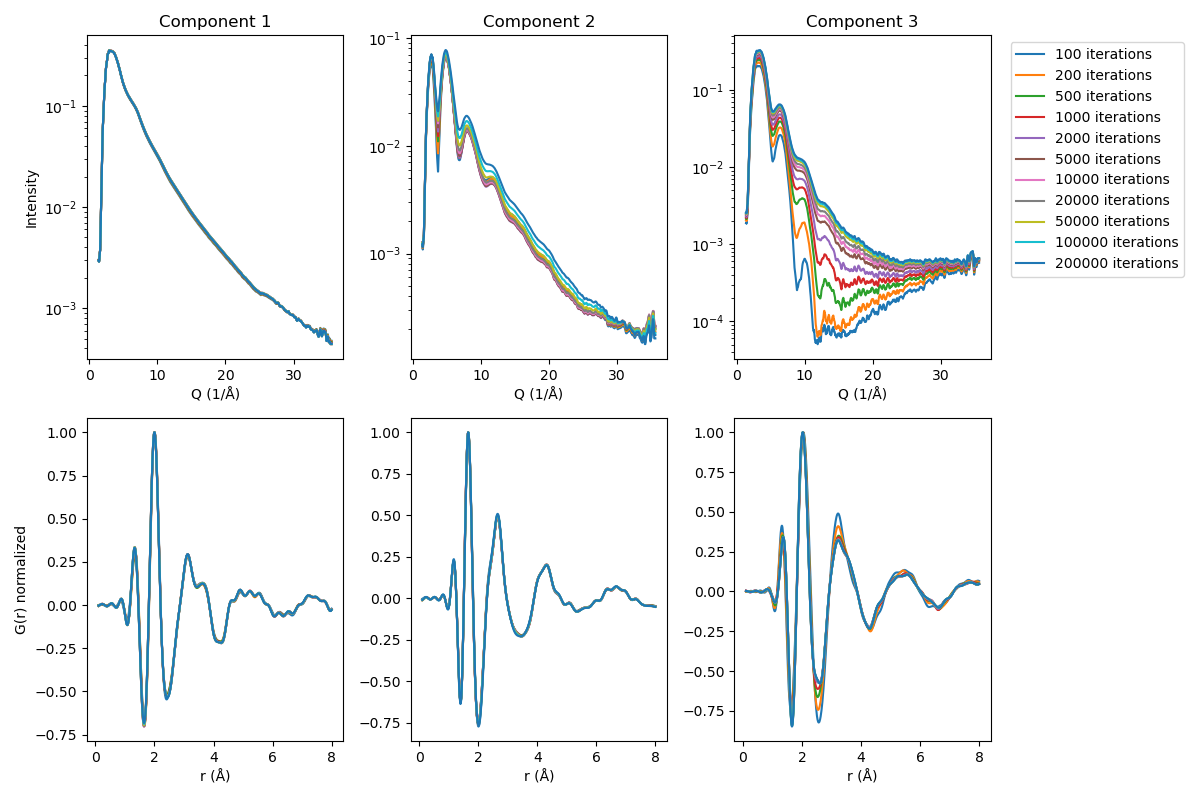

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(12,8))
labels = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000]
components_list = [H_NQ_100, H_NQ_200, H_NQ_500, H_NQ, H_NQ_2000, H_NQ_5000, H_NQ_10000, H_NQ_20000, H_NQ_50000, H_NQ_100000, H_NQ_200000]

for c in range(3):
    ax_top = axes[0, c]
    ax_bot = axes[1, c]
    
    for ix, comp_set in enumerate(components_list):
        component = comp_set[c]
        diff = component.reshape((x_reci, y_reci))
        QA, I, ai = integrate_single(diff, meta, beamstop.T, ai_res=2**11, return_AI=True)
        
        ax_top.plot(QA, I, label=f"{labels[ix]} iterations")
        
        pdfr, pdfgr, [qmin, qmax, p] = pdf_optimize(QA, I, qmin=2.5, qmax=20, rpolyrange=np.arange(1, 2, 0.01))
        ax_bot.plot(pdfr[pdfr < 8], pdfgr[pdfr < 8] / pdfgr.max(), label=f"{labels[ix]} iterations")

    ax_top.set_yscale('log')
    ax_top.set_title(f"Component {c+1}")
    ax_top.set_xlabel("Q (1/Å)")
    if c == 0:
        ax_top.set_ylabel("Intensity")
    
    # ax_bot.set_title(f"Component {c+1}")
    ax_bot.set_xlabel("r (Å)")
    if c == 0:
        ax_bot.set_ylabel("G(r) normalized")

axes[0, 2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('figures/TiO2_convergence.png', dpi=300, bbox_inches='tight')

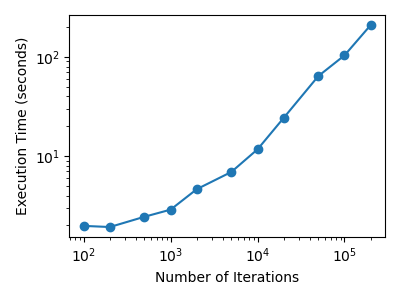

In [ ]:
# Plot execution times vs number of iterations
plt.figure(figsize=(4,3))
if execution_times:
    iterations = sorted(execution_times.keys())
    times = [execution_times[i] for i in iterations]
    
    plt.plot(iterations, times, marker='o')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Number of Iterations')
    plt.ylabel('Execution Time (seconds)')
    plt.tight_layout()
    # plt.savefig('figures/TiO2_execution_time.png', dpi=300) # refer to TiO2_convergence_time for a better approach
    plt.show()